# DATA COLLECTION AND PROCESSING

## Webscraping

### OCW

In [ ]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import pandas as pd
import csv

# === Load Excel File === 
excel_path = "/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/NY_output-1748181218864.xlsx"
df = pd.read_excel(excel_path)

# === Output CSV File ===
output_csv = "ocw_lecture_notes_only.csv"
with open(output_csv, mode="w", newline='', encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow([
        "Course Page", "Section", "PDF Title", "PDF URL",
        "resource-type", "Down_link",
        "topic-link", "topic-link 2", "topic-link 3"
    ])

    # === Iterate through course pages ===
    for idx, row in df.iterrows():
        page_url = row.get("Down_link")
        if not isinstance(page_url, str) or not page_url.startswith("http"):
            print(f"❌ Invalid URL at row {idx}: {page_url}")
            continue

        try:
            print(f"\n🔎 Scraping Lecture Notes from: {page_url}")
            response = requests.get(page_url)
            response.raise_for_status()
            soup = BeautifulSoup(response.text, "html.parser")

            # Find the Lecture Notes section
            lecture_notes_div = soup.find("div", id="resource-list-container-lecture-notes")
            if not lecture_notes_div:
                print("⚠️ No 'Lecture Notes' section found.")
                continue

            count = 0
            for tag in lecture_notes_div.select('a.resource-thumbnail[href$=".pdf"]'):
                href = tag.get("href")
                full_url = urljoin("https://ocw.mit.edu", href)
                filename = href.split("/")[-1]

                writer.writerow([
                    page_url, "Lecture Notes", filename, full_url,
                    row.get("resource-type", ""),
                    page_url,
                    row.get("topic-link", ""),
                    row.get("topic-link 2", ""),
                    row.get("topic-link 3", "")
                ])
                print(f"  📄 {filename} — {full_url}")
                count += 1

            print(f"✅ Total Lecture Note PDFs: {count}")

        except Exception as e:
            print(f"❌ Error processing {page_url}: {e}")

print(f"\n✅ Done. Results saved to '{output_csv}'")

#### pdf to txt and json

In [ ]:
import os
import random
import json
from pdfminer.high_level import extract_text

def pdf_to_text(pdf_path):
    """
    Extract text from a PDF using pdfminer.
    """
    try:
        text = extract_text(pdf_path)
        return text
    except Exception as e:
        print(f"Error extracting text from {pdf_path}: {e}")
        return ""

def main():
    # Specify the folder containing PDFs
    pdf_folder = "/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/downloaded_lecture_notes"
    
    # Collect all PDF files in the folder
    all_pdfs = [f for f in os.listdir(pdf_folder) if f.lower().endswith(".pdf")]
    
    # Randomly sample 10 PDFs (ensure there are at least 10 PDFs in the folder)
    sample_size = 2813
    if len(all_pdfs) < sample_size:
        print(f"Not enough PDF files found. Found {len(all_pdfs)}, need at least {sample_size}.")
        return
    
    random_pdfs = random.sample(all_pdfs, sample_size)
    
    # Create output folders for text and json (if needed)
    text_output_folder = os.path.join(pdf_folder, "text")
    json_output_folder = os.path.join(pdf_folder, "json")
    
    os.makedirs(text_output_folder, exist_ok=True)
    os.makedirs(json_output_folder, exist_ok=True)
    
    for pdf_file in random_pdfs:
        pdf_path = os.path.join(pdf_folder, pdf_file)
        
        # Extract text from PDF
        extracted_text = pdf_to_text(pdf_path)
        
        # Prepare output filenames
        base_name = os.path.splitext(pdf_file)[0]
        txt_filename = f"{base_name}.txt"
        json_filename = f"{base_name}.json"
        
        # Save as .txt
        txt_path = os.path.join(text_output_folder, txt_filename)
        with open(txt_path, "w", encoding="utf-8") as txt_file:
            txt_file.write(extracted_text)
        
        # Save as .json
        json_path = os.path.join(json_output_folder, json_filename)
        json_data = {
            "filename": pdf_file,
            "content": extracted_text
        }
        with open(json_path, "w", encoding="utf-8") as json_file:
            json.dump(json_data, json_file, ensure_ascii=False, indent=4)
        
        print(f"Processed: {pdf_file}")

if __name__ == "__main__":
    main()

Processed: ff37c163bb121bc9e450fb788d736181_6252_slides05.pdf
Processed: cda4e0bac613154fc8bf04506de5df1f_Slides1.pdf
Processed: d271a338f6d6db8bf70df4ad95d805d6_lec10.pdf
Processed: 1a592ed184fb4c444547f67c9bcdd8ec_MIT6_436JF18_lec13.pdf
Processed: 889d9ff44af28fa599c0588c9b4f9ec9_l04.pdf
Processed: 6254accbbe56e6cdd24d2916bcdbccd3_lec4.pdf
Processed: 6a77c25467108764576f82f7f0f4e12a_MIT6_088IAP10_lec06.pdf
Processed: e8a6314637f3ca051209b068984d3f46_MIT6_837F12_Lec22.pdf
Processed: d43f1dff422e9519bfab3d63a339a1a4_qc_lec05.pdf
Processed: 8ec5c46c02da5d65885ccce05951393d_robopsy_slide.pdf
Processed: c6d52bc904f5f6e592413e7dca1551ea_MIT6_046JS12_lec12.pdf
Processed: a05dca53b5cd67963a6e93ef3952b5e4_rpra2.pdf
Processed: 84ea6cf153a2841c6fb7d25812bd69ff_lec3.pdf
Processed: e82e41efd0d2c97f14c8fc8e44076e68_l02.pdf
Processed: 4a50951d57336f8ffb8af8fbfbb22b4d_lecture4.pdf
Processed: aff4e7915b3de35e2481d62b444d71ee_MIT6_011S18lec17.pdf
Processed: 35c1c5bbf304c0f41e1de0cec0b0ee85_MIT2_61S17_

In [ ]:
import os
import json
import pandas as pd

# === 1. CONFIGURATION ===
json_dir = "/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/json"
metadata_csv_path = "/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/ocw_lecture_notes_with_analysis.csv"
full_output_csv = "raw_json_text_with_source.csv"
preview_csv = "raw_json_text_with_source_head20.csv"

# === 2. LOAD METADATA CSV ===
metadata_df = pd.read_csv(metadata_csv_path)
metadata_df["PDF Title"] = metadata_df["PDF Title"].astype(str).str.strip()
metadata_lookup = metadata_df.set_index("PDF Title")["PDF URL"].to_dict()

# === 3. PROCESS JSON FILES ===
json_rows = []

for filename in sorted(os.listdir(json_dir)):
    if not filename.endswith(".json"):
        continue

    title_key = filename.replace(".json", ".pdf")
    pdf_url = metadata_lookup.get(title_key, "NOT FOUND")
    
    file_path = os.path.join(json_dir, filename)

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, dict) and "content" in data:
            text = data["content"]
        else:
            text = json.dumps(data)  # fallback: serialize entire object

        json_rows.append({
            "text": text,
            "source": pdf_url
        })

    except Exception as e:
        print(f"⚠️ Error reading {filename}: {e}")

# === 4. SAVE FULL CSV ===
df = pd.DataFrame(json_rows)
df.to_csv(full_output_csv, index=False)
print(f"✅ Full CSV saved: {full_output_csv} ({len(df)} rows)")

# === 5. SAVE FIRST 20 ROWS FOR CHECKING ===
df.head(20).to_csv(preview_csv, index=False)
print(f"✅ Preview CSV saved (first 20 rows): {preview_csv}")

# TOKENIZATION AND CLEANING

### OCW

In [9]:
### === 0. IMPORTS AND SETUP ===
import os
import re
import json
import pandas as pd
from langdetect import detect
from transformers import AutoTokenizer
from tqdm import tqdm

# === CONFIGURATION ===
input_csv = "/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/raw_json_text_with_source.csv"
output_json_path = "ocw_chunks.json"
max_tokens = 490
overlap = 32

# === LOAD TOKENIZER (Qwen) ===
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B-Base")

# === CHUNKING FUNCTION ===
def chunk_text(text, max_tokens=512, overlap=32, tokenizer=tokenizer):
    # Use the Qwen tokenizer
    tokens = tokenizer.encode(text, add_special_tokens=False)
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))
        chunk_tokens = tokens[start:end]
        chunk = tokenizer.decode(chunk_tokens)
        chunks.append(chunk)
        start += max_tokens - overlap
    return chunks

# === CLEANING FUNCTION ===
def clean_chunk(chunk):
    if len(chunk) < 50:
        return None
    try:
        if detect(chunk) != "en":
            return None
    except:
        return None

    junk_ratio = sum(c in "!@#$%^&*_~`" for c in chunk) / len(chunk)
    if junk_ratio > 0.2:
        return None

    chunk = re.sub(r"\n+", "\n", chunk)
    chunk = re.sub(r"[ \t]+", " ", chunk)
    return chunk.strip()

# === MAIN PROCESSING ===
all_data = []

df = pd.read_csv(input_csv)
df["text"] = df["text"].astype(str)
df["source"] = df["source"].astype(str)

for idx, row in tqdm(df.iterrows(), total=len(df), desc="🔍 Processing CSV rows"):
    text = row["text"]
    source = row["source"]

    chunks = chunk_text(text, max_tokens=max_tokens, overlap=overlap, tokenizer=tokenizer)
    for j, chunk in enumerate(chunks):
        cleaned = clean_chunk(chunk)
        if cleaned:
            all_data.append({
                "source": source,
                "chunk_id": f"{idx}_{j}",
                "text": cleaned,
                "char_len": len(cleaned),
                "chunk_index": j
            })

# === SAVE OUTPUT ===
with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(all_data, f, indent=2, ensure_ascii=False)

print(f"\n📦 Done! Saved {len(all_data)} clean RAG chunks to: {output_json_path}")

🔍 Processing CSV rows: 100%|██████████| 2813/2813 [01:55<00:00, 24.28it/s]



📦 Done! Saved 35610 clean RAG chunks to: ocw_chunks.json


Total chunks: 35610
Chunks with >512 tokens: 0 (0.00%)

Token count statistics:
  Min: 10
  25th percentile: 412.0
  Median: 473.0
  75th percentile: 489.0
  Max: 510


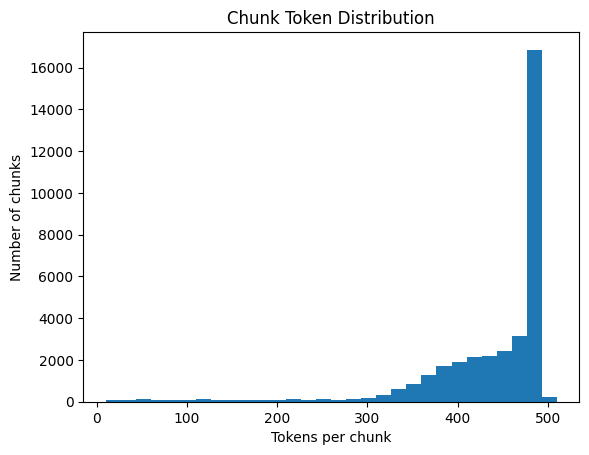

In [12]:
import json
from collections import Counter
from transformers import AutoTokenizer

# Load the tokenizer and chunks
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B-Base")
with open("ocw_chunks.json", "r", encoding="utf-8") as f:
    chunks = json.load(f)

# Count tokens for each chunk
token_counts = [len(tokenizer.encode(chunk["text"], add_special_tokens=False)) for chunk in chunks]

# How many are over the limit?
max_tokens = 512
over_limit = [c for c in token_counts if c > max_tokens]
num_over = len(over_limit)
num_chunks = len(token_counts)

print(f"Total chunks: {num_chunks}")
print(f"Chunks with >{max_tokens} tokens: {num_over} ({100*num_over/num_chunks:.2f}%)")
if num_over > 0:
    print("Max token count among over-limit chunks:", max(over_limit))

# Print token distribution summary
import numpy as np
print("\nToken count statistics:")
print(f"  Min: {np.min(token_counts)}")
print(f"  25th percentile: {np.percentile(token_counts, 25):.1f}")
print(f"  Median: {np.median(token_counts):.1f}")
print(f"  75th percentile: {np.percentile(token_counts, 75):.1f}")
print(f"  Max: {np.max(token_counts)}")

# (Optional) Histogram
import matplotlib.pyplot as plt
plt.hist(token_counts, bins=30)
plt.xlabel("Tokens per chunk")
plt.ylabel("Number of chunks")
plt.title("Chunk Token Distribution")
plt.show()

In [ ]:
ocw_chunks.json

[{'source': 'https://ocw.mit.edu/courses/18-156-differential-analysis-spring-2004/001210200bdd9ab37d9c20bf897d605f_da5.pdf',
  'chunk_id': '0_0',
  'text': 'Lecture 16\nApril 13th, 2004\nElliptic regularity\nHitherto we have always assumed our solutions already lie in the appropriate Ck,α space and\nthen showed estimates on their norms in those spaces. Now we will avoid this a priori assumption\nand show that they do hold a posteriori. This is important for the consistency of our discussion.\nPrecisely what we would like to show is —\nA priori regularity.\nLet u ∈ C2(Ω) be a solution of Lu = f and assume 0 < α < 1. We\ndo not assume c(x) ≤ 0 but we do assume all the other assumptions on L in the previous Theorem\nhold. If f ∈ Cα(Ω) then u ∈ C2,α(Ω)\n• Here we mean the Cα norm is locally bounded, i.e for every point exists a neighborhood where\nthe Cα-norm is bounded. Had we written Cα( ¯Ω) we would mean a global bound on sup\nx,y\n|f (x) − f (y)|\n|x − y|α\n(as in the footnote if Lectu

### Wikibooks

In [ ]:
import pandas as pd

# === Configuration ===
input_path = "/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/wiki_stem_corpus.csv"
output_path = "wiki_stem_text_with_source.csv"
source_url = "https://www.kaggle.com/datasets/conjuring92/wiki-stem-corpus"

# === Load only valid lines from CSV ===
df = pd.read_csv(input_path, on_bad_lines="skip", engine="python")

# === Keep only text and add source ===
df_clean = df[["text"]].copy()
df_clean["source"] = source_url

# === Save as simplified CSV ===
df_clean.to_csv(output_path, index=False)
print(f"✅ Saved {len(df_clean)} rows to {output_path}")

In [ ]:
import pandas as pd

# 1. Load your data
fp = "/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/wiki_stem_text_with_source.csv"
df = pd.read_csv(fp)

# 2. Define keywords
include_keywords = [
    "computer", "algorithm", "programming", "data", 
    "network", "math", "mathematics", "calculus", "theorem", 
    "physics", "quantum", "particle", "relativity"
]
exclude_keywords = [
    "economy", "economic", "finance", "investment", 
    "marketing", "business", "advertising", "stock"
]

# Build regex patterns
inc_pat = r"(?i)\b(?:" + "|".join(include_keywords) + r")\b"
exc_pat = r"(?i)\b(?:" + "|".join(exclude_keywords) + r")\b"

# 3. Filter
mask_inc = df["text"].str.contains(inc_pat, regex=True, na=False)
mask_exc = df["text"].str.contains(exc_pat, regex=True, na=False)
df_filtered = df[mask_inc & ~mask_exc].copy()

# 4. (Optional)
print(f"Kept {len(df_filtered):,} rows out of {len(df):,} total")

# 5. Save to a new CSV
out_fp = fp.replace(".csv", "_cs_math_physics.csv")
df_filtered.to_csv(out_fp, index=False)
print("Written filtered data to", out_fp)


Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors


Total rows: 397697
Token length (mean): 125.64
Token length (min): 6
Token length (max): 679
Token length (median): 112.0
Token length (95th percentile): 254.00
Token length (99th percentile): 381.00
Rows with >512 tokens: 248 (0.06%)


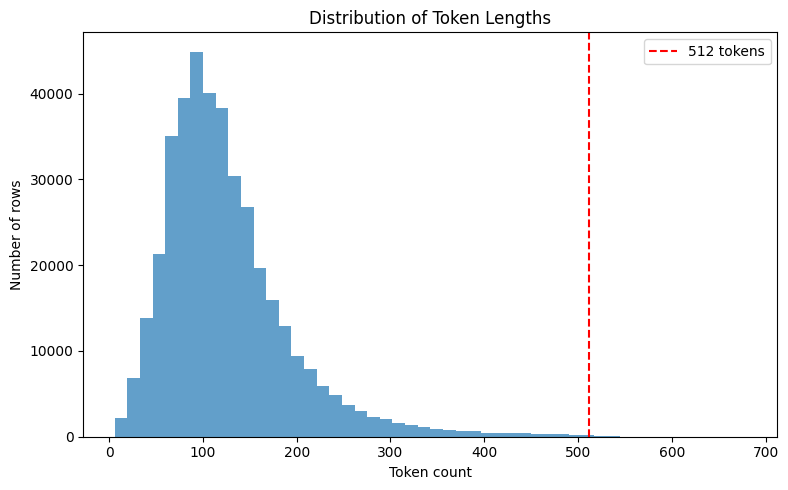

In [ ]:
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

# === CONFIGURATION ===
input_fp = Path("/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/wiki_stem_text_with_source_cs_math_physics.csv")
tokenizer_name = "BAAI/bge-small-en-v1.5"

# === LOAD DATA ===
df = pd.read_csv(input_fp)
if "text" not in df.columns:
    raise ValueError("Column 'text' not found in CSV.")

# === LOAD TOKENIZER ===
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

# === TOKENIZE & ANALYZE ===
token_lens = []
for text in df["text"]:
    tokens = tokenizer.encode(str(text), add_special_tokens=False)
    token_lens.append(len(tokens))

token_lens = np.array(token_lens)

# === PRINT BASIC STATS ===
print(f"Total rows: {len(df)}")
print(f"Token length (mean): {np.mean(token_lens):.2f}")
print(f"Token length (min): {np.min(token_lens)}")
print(f"Token length (max): {np.max(token_lens)}")
print(f"Token length (median): {np.median(token_lens)}")
print(f"Token length (95th percentile): {np.percentile(token_lens, 95):.2f}")
print(f"Token length (99th percentile): {np.percentile(token_lens, 99):.2f}")

# === OPTIONAL: HOW MANY EXCEED 512 ===
over_512 = np.sum(token_lens > 512)
print(f"Rows with >512 tokens: {over_512} ({100*over_512/len(df):.2f}%)")

# === HISTOGRAM ===
plt.figure(figsize=(8,5))
plt.hist(token_lens, bins=50, alpha=0.7)
plt.title("Distribution of Token Lengths")
plt.xlabel("Token count")
plt.ylabel("Number of rows")
plt.axvline(512, color='red', linestyle='--', label='512 tokens')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer

# === LOAD CSV ===
input_fp = "/Users/nil.ilba/Documents/1.EPFL/MA4_25_Spring/MNLP_M2/wiki_stem_text_with_source_cs_math_physics.csv"
df = pd.read_csv(input_fp)

# === LOAD TOKENIZER ===
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-small-en-v1.5")

# === COMPUTE TOKEN LENGTHS ===
df["token_len"] = df["text"].astype(str).apply(lambda x: len(tokenizer.encode(x, add_special_tokens=False)))

# === FILTER: Keep only rows <= 512 tokens ===
df_filtered = df[df["token_len"] <= 512].copy()

print(f"Rows under 512 tokens: {len(df_filtered)}")

# === SELECT TOP 64,390 LONGEST (under 512) ===
top_n = 64390
df_top = df_filtered.nlargest(top_n, "token_len").copy()

print(f"Selected {len(df_top)} rows with highest token counts (<=512 tokens)")

# === (OPTIONAL) SAVE THE RESULT ===
df_top.to_csv("wikibooks_64390_chunks.csv", index=False)
print("Saved as 'wikibooks_64390_chunks.csv'.")

# === SHOW BASIC STATS ===
print(df_top["token_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors


Rows under 512 tokens: 397449
Selected 64390 rows with highest token counts (<=512 tokens)
Saved as 'wikibooks_64390_chunks.csv'.
count    64390.000000
mean       243.974095
std         66.503455
min        179.000000
50%        221.000000
90%        339.000000
95%        392.000000
99%        475.000000
max        512.000000
Name: token_len, dtype: float64


In [ ]:
df_top 
#wikibooks_64390_chunks

,text,source,token_len
37152,"Let G = ( V , E ) {\displaystyle G=(V,E)} be a...",https://www.kaggle.com/datasets/conjuring92/wi...,512
39011,"Like most other EAs, BBO includes mutation. A ...",https://www.kaggle.com/datasets/conjuring92/wi...,512
67986,One of the simplest methods is linear interpol...,https://www.kaggle.com/datasets/conjuring92/wi...,512
86613,Recent research has shown that the kernel and ...,https://www.kaggle.com/datasets/conjuring92/wi...,512
108507,"Stenger, Victor; Slater, W. E.; Stork, D. H.; ...",https://www.kaggle.com/datasets/conjuring92/wi...,512
...,...,...,...
274495,IACT stands for Imaging Atmospheric (or Air) C...,https://www.kaggle.com/datasets/conjuring92/wi...,179
274513,IAR Embedded Workbench – a development environ...,https://www.kaggle.com/datasets/conjuring92/wi...,179
275522,The purpose was to identify IPA symbols explic...,https://www.kaggle.com/datasets/conjuring92/wi...,179
275523,IPA was involved in the International Polar Ye...,https://www.kaggle.com/datasets/conjuring92/wi...,179


## Combined

In [ ]:
import pandas as pd
import json
from datasets import Dataset
from huggingface_hub import notebook_login

# --- 1. Load Data ---

# Wikibooks CSV
wikibooks_fp = "wikibooks_64390_chunks.csv"   
df_wikibooks = pd.read_csv(wikibooks_fp)

# OCW JSON
with open("ocw_chunks.json", "r") as f:
    ocw_chunks = json.load(f)
df_ocw = pd.DataFrame(ocw_chunks)

# --- 2. Keep only 'text' and 'source' columns ---
df_wikibooks = df_wikibooks[["text", "source"]]
df_ocw = df_ocw[["text", "source"]]

# --- 3. Combine, OCW first ---
df_combined = pd.concat([df_ocw, df_wikibooks], ignore_index=True)
print(f"Combined dataset: {len(df_combined)} rows")

# --- 4. Save to JSON (optional but useful for checking) ---
df_combined.to_json("combined_chunks.json", orient="records", force_ascii=False, indent=2)

# --- 5. Push to Hugging Face Hub ---

# Load as HF Dataset
hf_dataset = Dataset.from_pandas(df_combined)

# Push to your repo
hf_dataset.push_to_hub("nililba/combined_wikibooks_ocw_chunks")

Combined dataset: 100000 rows


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/100 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/nililba/combined_wikibooks_ocw_chunks/commit/a1af82dc6f3a8d019c7fc4921c415f4093b16f6f', commit_message='Upload dataset', commit_description='', oid='a1af82dc6f3a8d019c7fc4921c415f4093b16f6f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/nililba/combined_wikibooks_ocw_chunks', endpoint='https://huggingface.co', repo_type='dataset', repo_id='nililba/combined_wikibooks_ocw_chunks'), pr_revision=None, pr_num=None)